# Probability Distributions and Statistical Tests

## Bernoulli Distribution

[0 0 0 0 1 1 1 1 1 1]


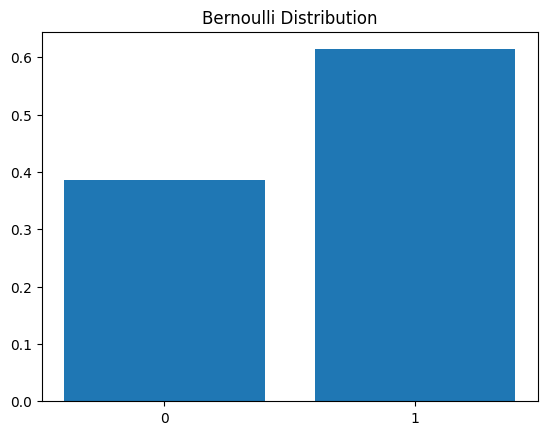

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bernoulli

p = 0.6
r = bernoulli.rvs(p, size=1000)
print(r[:10])

plt.hist(r, bins=[-0.5, 0.5, 1.5], rwidth=0.8, density=True)
plt.xticks([0, 1])
plt.title('Bernoulli Distribution')
plt.show()

## Binomial Distribution

[4 3 6 4 3 1 4 3 5 7]


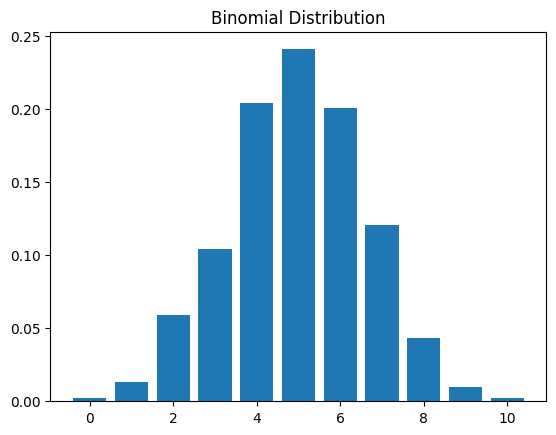

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

n, p = 10, 0.5
r = binom.rvs(n, p, size=1000)
print(r[:10])

plt.hist(r, bins=np.arange(-0.5, n + 1.5, 1), rwidth=0.8, density=True)
plt.title('Binomial Distribution')
plt.show()

## Common Discrete Probability Distributions

[2 3 1 4 5 1 2 4 2 5]


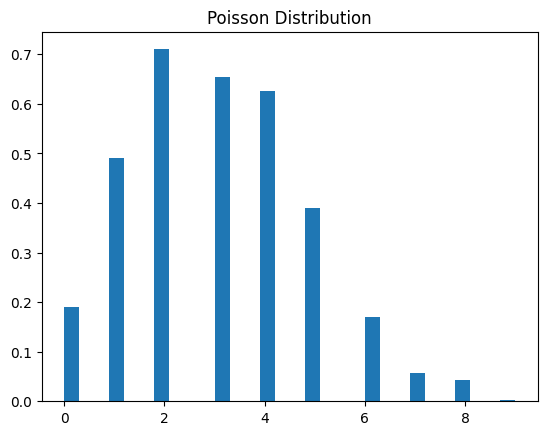

[3 2 1 4 2 1 1 3 1 3]


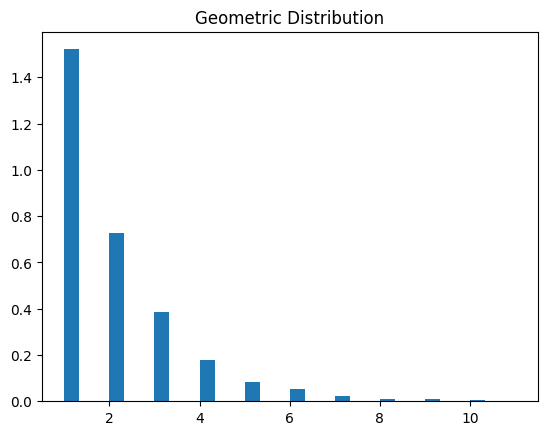

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, geom

mu = 3
r_poisson = poisson.rvs(mu, size=1000)
print(r_poisson[:10])

plt.hist(r_poisson, bins=30, density=True)
plt.title('Poisson Distribution')
plt.show()

p_geom = 0.5
r_geom = geom.rvs(p_geom, size=1000)
print(r_geom[:10])

plt.hist(r_geom, bins=30, density=True)
plt.title('Geometric Distribution')
plt.show()

## Common Continuous Probability Distributions

[ 0.10379951 -0.04542501  0.0243132  -0.12027656  0.13833976 -0.15563452
  0.13560713 -0.15265267 -0.08215142 -0.08161991]


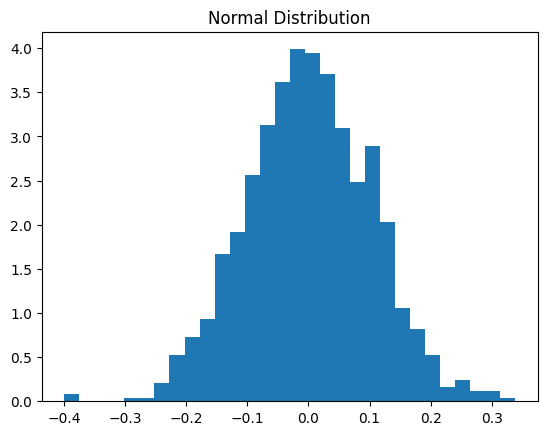

[1.88578277 0.37594204 0.9832969  8.09470851 1.17377436 0.13090551
 0.13797486 2.56006949 0.02790501 0.43405484]


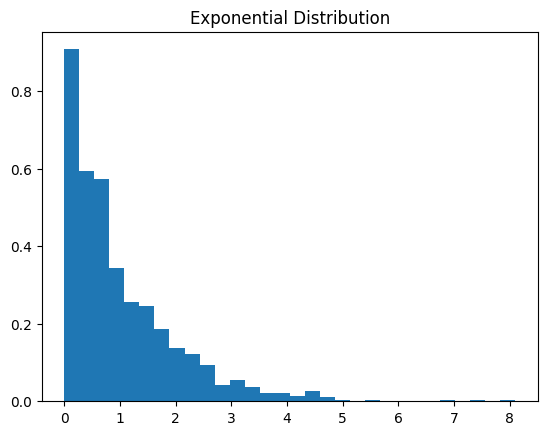

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, expon

mu, sigma = 0, 0.1
r_norm = norm.rvs(mu, sigma, size=1000)
print(r_norm[:10])

plt.hist(r_norm, bins=30, density=True)
plt.title('Normal Distribution')
plt.show()

scale = 1.0
r_expon = expon.rvs(scale=scale, size=1000)
print(r_expon[:10])

plt.hist(r_expon, bins=30, density=True)
plt.title('Exponential Distribution')
plt.show()

## Z-Test

In [5]:
import numpy as np
from scipy.stats import norm

np.random.seed(42)
population = np.random.randint(50, 96, 1000)
sample_size = int(0.10 * len(population))
sample = np.random.choice(population, size=sample_size, replace=False)

population_mean = np.mean(population)
population_std = np.std(population)
sample_mean = np.mean(sample)

z_score = (sample_mean - population_mean) / (population_std / np.sqrt(sample_size))
p_value = 2 * (1 - norm.cdf(abs(z_score)))

print('Z-score:', z_score)
print('P-value:', p_value)

Z-score: -0.3723468612704036
P-value: 0.7096346125444655


## Independent t-test

In [6]:
import numpy as np
from scipy import stats

group1 = np.array([12, 15, 14, 16, 18])
group2 = np.array([10, 12, 11, 13, 15])

t_stat, p_val = stats.ttest_ind(group1, group2)
print('T-statistic:', t_stat)
print('P-value:', p_val)

T-statistic: 2.1226745220209304
P-value: 0.06654757650534854


## Parametric Statistical Tests

In [7]:
import numpy as np
from scipy import stats
from statsmodels.stats.weightstats import ztest
from statsmodels.stats.proportion import proportions_ztest

np.random.seed(42)
group1 = np.random.normal(loc=70, scale=10, size=30)
group2 = np.random.normal(loc=75, scale=10, size=30)
group3 = np.random.normal(loc=80, scale=10, size=30)
before = np.random.normal(loc=65, scale=8, size=30)
after = before + np.random.normal(loc=5, scale=4, size=30)

z_stat, p_value = ztest(group1, value=70)
print('One Sample Z-test P-value:', p_value)

z_stat, p_value = ztest(group1, group2)
print('Two Sample Z-test P-value:', p_value)

z_stat, p_value = proportions_ztest(count=60, nobs=100, value=0.50)
print('One Proportion Z-test P-value:', p_value)

z_stat, p_value = proportions_ztest(count=np.array([60, 75]), nobs=np.array([100, 120]))
print('Two Proportion Z-test P-value:', p_value)

t_stat, p_value = stats.ttest_1samp(group1, popmean=70)
print('One Sample T-test P-value:', p_value)

t_stat, p_value = stats.ttest_rel(before, after)
print('Paired T-test P-value:', p_value)

f_stat, p_value = stats.f_oneway(group1, group2, group3)
print('One-Way ANOVA P-value:', p_value)

x = np.random.normal(50, 10, 30)
y = x + np.random.normal(5, 5, 30)
r_value, p_value = stats.pearsonr(x, y)
print('Pearson Correlation P-value:', p_value)

slope, intercept, r_value, p_value, std_error = stats.linregress(x, y)
print('Simple Linear Regression P-value:', p_value)

One Sample Z-test P-value: 0.25220196328281785
Two Sample Z-test P-value: 0.01647968360202956
One Proportion Z-test P-value: 0.0412268333371637
Two Proportion Z-test P-value: 0.7045411044459733
One Sample T-test P-value: 0.2615641461880129
Paired T-test P-value: 9.807312225268125e-07
One-Way ANOVA P-value: 2.1200748140506923e-05
Pearson Correlation P-value: 1.218646394799568e-13
Simple Linear Regression P-value: 1.2186463947995898e-13


## Non-Parametric Statistical Tests

In [8]:
import numpy as np
from scipy import stats

group1 = np.array([12, 15, 14, 16, 18, 20, 22])
group2 = np.array([10, 12, 11, 13, 15, 14, 16])

u_stat, mwu_p = stats.mannwhitneyu(group1, group2)
print('Mann-Whitney U P-value:', mwu_p)

w_stat, wilc_p = stats.wilcoxon(group1, group2)
print('Wilcoxon Signed-Rank P-value:', wilc_p)

h_stat, kruskal_p = stats.kruskal(group1, group2)
print('Kruskal-Wallis P-value:', kruskal_p)

Mann-Whitney U P-value: 0.054215548297750465
Wilcoxon Signed-Rank P-value: 0.015625
Kruskal-Wallis P-value: 0.046670223729794104
